# Room-Temperature Body-Diode ANN

In [2]:
# Import the room-temperature data loader and body-diode ANN.
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from CV_DeviceData import load_body_diode_characteristics
from body_diode_hybrid import (
    train_ibd_network,
    predict_ibd,
    save_ibd_pkl,
    load_ibd_pkl,
)


## Load the room-temperature body-diode dataset

In [3]:
# Read every Vgs curve from the 25 C body-diode folder.
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "Template"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = load_body_diode_characteristics(TEMPLATE_DIR)

print(df.groupby(["T_C", "Vgs"]).size())
print("Total body-diode points =", len(df))

assert np.allclose(
    df["T_C"].to_numpy(),
    25.0,
)

Vgs = torch.tensor(
    df["Vgs"].to_numpy(np.float32),
    dtype=torch.float32,
).reshape(-1, 1)

Vds = torch.tensor(
    df["Vds"].to_numpy(np.float32),
    dtype=torch.float32,
).reshape(-1, 1)

Ibd = torch.tensor(
    df["Ibd"].to_numpy(np.float32),
    dtype=torch.float32,
).reshape(-1, 1)

MODEL_FILE = BASE_DIR / "Ibd_NN.pkl"

print("Device =", device)
print(
    "Vds range =",
    float(Vds.min()),
    "to",
    float(Vds.max()),
    "V",
)
print(
    "Ibd range =",
    float(Ibd.min()),
    "to",
    float(Ibd.max()),
    "A",
)


T_C   Vgs 
25.0  -5.0    30
      -2.0    29
       0.0    36
dtype: int64
Total body-diode points = 95
Device = cpu
Vds range = -6.5748372077941895 to 0.0 V
Ibd range = -70.0 to 0.0 A


## Train Eq. (29) at room temperature

In [4]:
# Use a longer training run without regional tail weighting.
EPOCHS = 20000
LEARNING_RATE = 1.0e-4
BATCH_SIZE = 128
VAL_FRACTION = 0.20
SEED = 42

# Additional loss weights for the sighn and zero regions. Or it will above 0 into 2. Quadrant.
SIGN_WEIGHT = 1.0
ZERO_WEIGHT = 1.0
ZERO_WIDTH = 0.50

model, norm, history = train_ibd_network(
    Vgs,
    Vds,
    Ibd,
    device=device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    val_fraction=VAL_FRACTION,
    seed=SEED,
    print_every=500,
    sign_weight=SIGN_WEIGHT,
    zero_weight=ZERO_WEIGHT,
    zero_width=ZERO_WIDTH,
)

print(
    "Best validation loss =",
    history.best_val_loss,
)


Epoch     1/20000 | train = 9.508108e-01 | val = 1.404520e+00
Epoch   500/20000 | train = 7.177043e-01 | val = 1.083779e+00
Epoch  1000/20000 | train = 4.366713e-01 | val = 6.999986e-01
Epoch  1500/20000 | train = 1.981288e-01 | val = 3.492698e-01
Epoch  2000/20000 | train = 1.202921e-01 | val = 2.112298e-01
Epoch  2500/20000 | train = 9.867315e-02 | val = 1.677865e-01
Epoch  3000/20000 | train = 8.231334e-02 | val = 1.418869e-01
Epoch  3500/20000 | train = 6.604192e-02 | val = 1.176440e-01
Epoch  4000/20000 | train = 5.026673e-02 | val = 9.330057e-02
Epoch  4500/20000 | train = 3.613335e-02 | val = 7.014070e-02
Epoch  5000/20000 | train = 2.486036e-02 | val = 5.021124e-02
Epoch  5500/20000 | train = 1.694463e-02 | val = 3.496928e-02
Epoch  6000/20000 | train = 1.190604e-02 | val = 2.448839e-02
Epoch  6500/20000 | train = 8.733635e-03 | val = 1.768309e-02
Epoch  7000/20000 | train = 6.614572e-03 | val = 1.324452e-02
Epoch  7500/20000 | train = 5.129286e-03 | val = 1.022738e-02
Epoch  8

In [5]:
# Save the trained room-temperature body-diode ANN.
save_ibd_pkl(
    MODEL_FILE,
    model,
    norm,
    training_metadata={
        "temperature_C": 25.0,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "validation_fraction": VAL_FRACTION,
        "seed": SEED,
        "best_validation_loss": float(
            history.best_val_loss
        ),
        "number_of_samples": int(
            len(df)
        ),
        "sign_weight": SIGN_WEIGHT,
        "zero_weight": ZERO_WEIGHT,
        "zero_width": ZERO_WIDTH,
        "regional_tail_weighting": False,
    },
)

print(
    "Saved =",
    MODEL_FILE,
)


Saved = c:\Users\zipeng\Desktop\NNProject\Neural-Network_Internship_2026\.github\src\Ibd_NN.pkl


## Static-characteristic accuracy

In [6]:
# Predict every datasheet point and report global and tail errors.
Ibd_pred = predict_ibd(
    model,
    norm,
    Vgs.reshape(-1),
    Vds.reshape(-1),
    device=device,
).cpu().numpy().reshape(-1)

Ibd_true = (
    Ibd.cpu()
    .numpy()
    .reshape(-1)
)

Vds_np = (
    Vds.cpu()
    .numpy()
    .reshape(-1)
)

error = (
    Ibd_pred
    - Ibd_true
)

rmse = float(
    np.sqrt(
        np.mean(
            error ** 2
        )
    )
)

mae = float(
    np.mean(
        np.abs(
            error
        )
    )
)

print(
    "RMSE =",
    rmse,
    "A",
)

print(
    "MAE =",
    mae,
    "A",
)


RMSE = 0.17349885404109955 A
MAE = 0.12477096915245056 A


In [7]:
# Report RMSE for each Vgs curve.
for vgs_value in sorted(
    df["Vgs"].unique()
):
    mask = np.isclose(
        df["Vgs"].to_numpy(),
        vgs_value,
    )

    curve_rmse = float(
        np.sqrt(
            np.mean(
                error[mask] ** 2
            )
        )
    )

    print(
        f"Vgs = {vgs_value:g} V | "
        f"RMSE = {curve_rmse:.6f} A"
    )


Vgs = -5 V | RMSE = 0.114479 A
Vgs = -2 V | RMSE = 0.163964 A
Vgs = 0 V | RMSE = 0.216466 A


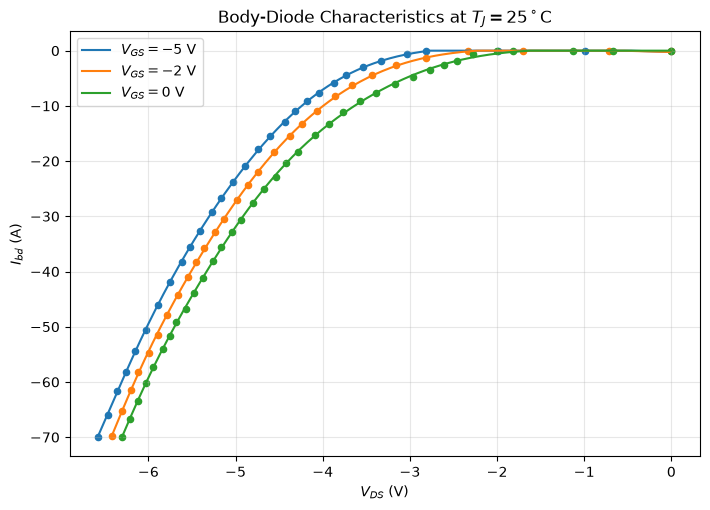

In [8]:
# Plot the datasheet points and ANN body-diode curves.
plt.figure(
    figsize=(7.2, 5.2)
)

for vgs_value in sorted(
    df["Vgs"].unique()
):
    measured = df[
        np.isclose(
            df["Vgs"],
            vgs_value,
        )
    ].sort_values(
        "Vds"
    )

    plt.scatter(
        measured["Vds"],
        measured["Ibd"],
        s=20,
    )

    Vds_curve = np.linspace(
        measured["Vds"].min(),
        0.0,
        300,
    )

    Vgs_curve = np.full_like(
        Vds_curve,
        vgs_value,
    )

    Ibd_curve = predict_ibd(
        model,
        norm,
        Vgs_curve,
        Vds_curve,
        device=device,
    ).cpu().numpy().reshape(-1)

    plt.plot(
        Vds_curve,
        Ibd_curve,
        label=rf"$V_{{GS}}={vgs_value:g}$ V",
    )

plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    r"$I_{bd}$ (A)"
)

plt.title(
    r"Body-Diode Characteristics at $T_J=25^\circ$C"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.legend()
plt.tight_layout()
plt.show()


In [9]:
# Verify that the saved checkpoint reloads independently.
model_loaded, norm_loaded, checkpoint = load_ibd_pkl(
    MODEL_FILE,
    device=device,
)

print(
    checkpoint["model_name"]
)

print(
    checkpoint["architecture"]
)

print(
    checkpoint["input_names"]
)

print(
    checkpoint["training_metadata"]
)


SiC_MOSFET_Body_Diode_ANN
{'input_dim': 2, 'hidden_dims': [6, 6], 'output_dim': 1, 'activation': 'tanh'}
['Vgs', 'Vds']
{'temperature_C': 25.0, 'epochs': 20000, 'learning_rate': 0.0001, 'batch_size': 128, 'validation_fraction': 0.2, 'seed': 42, 'best_validation_loss': 9.122845949605107e-05, 'number_of_samples': 95, 'sign_weight': 1.0, 'zero_weight': 1.0, 'zero_width': 0.5, 'regional_tail_weighting': False}


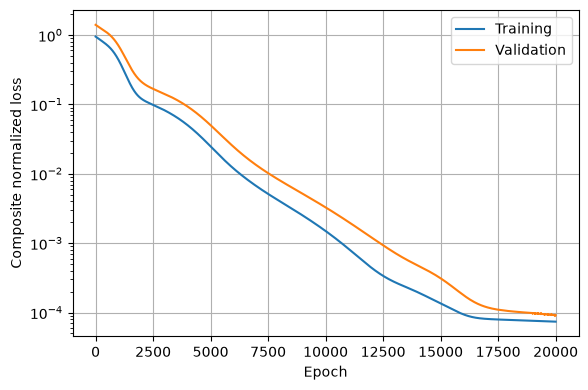

In [10]:
# Plot the training and validation composite losses.
plt.figure(
    figsize=(6, 4)
)

plt.semilogy(
    history.train_loss,
    label="Training",
)

plt.semilogy(
    history.val_loss,
    label="Validation",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Composite normalized loss"
)

plt.grid(
    True
)

plt.legend()
plt.tight_layout()
plt.show()
